# Currency Circuit Tracing

<a target="_blank" href="https://colab.research.google.com/github/yonadaa/currency-circuit-tracing/blob/main/currency_circuit_tracing.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook explores the country-specific features that activate when an LLM is asked the currency of a given city, eg. an "India" feature that activates when the answer is INR.

First, we define a dataset and prompt and verify that the model answers the correct currency for each city. Then we ablate and inject manually discovered country features, and graph their effect on the model's prediction for a specific prompt.

Step 0: Set up environment and model.

In [ ]:
# @title Colab Setup Environment

try:
    import google.colab

    !mkdir -p repository && cd repository && \
     git clone https://github.com/safety-research/circuit-tracer && \
     curl -LsSf https://astral.sh/uv/install.sh | sh && \
     uv pip install -e circuit-tracer/

    import sys
    from huggingface_hub import notebook_login

    sys.path.append("repository/circuit-tracer")
    sys.path.append("repository/circuit-tracer/demos")
    notebook_login(new_session=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [ ]:
from collections import namedtuple
from typing import List, Dict

import torch

from circuit_tracer import ReplacementModel
from circuit_tracer.utils.demo_utils import extract_supernode_features

backend = 'transformerlens'  # change to 'nnsight' for the nnsight backend!
model = ReplacementModel.from_pretrained("google/gemma-2-2b", "gemma", dtype=torch.bfloat16, backend=backend)

Step 1: Define the dataset and prompt template.

In [3]:
# Define dataset

countries = {
    "India": {
        "ticker": "INR",
        "cities": ["Mumbai", "Delhi", "Chennai", "Kolkata", "Bangalore", "Hyderabad"],
    },
    "United Kingdom": {
        "ticker": "GBP",
        "cities": ["London", "Manchester", "Birmingham", "Edinburgh", "Liverpool", "Bristol"],
    },
}

prompt_template = "Paris:EUR :: Tokyo:JPY :: {}:"

Step 2: Verify that the model correctly completes the prompt for every city in the dataset.

In [4]:
# Baseline check - can the model predict the correct currency?

# --- Helper to get top predictions ---
def get_top_outputs(logits, k=5):
    top_probs, top_token_ids = logits.squeeze(0)[-1].softmax(-1).topk(k)
    top_tokens = [model.tokenizer.decode(token_id) for token_id in top_token_ids]
    return list(zip(top_tokens, top_probs.tolist()))

print("=" * 70)
print("Baseline: Can the model predict the correct currency?")
print("=" * 70)

for country, info in countries.items():
    print(f"\n  {country} (expected: {info['ticker']})")
    for city in info["cities"]:
        prompt = prompt_template.format(city)
        logits, _ = model.get_activations(prompt)
        top = get_top_outputs(logits)
        top_token = top[0][0].strip()
        match = "✓" if top_token == info["ticker"] else "✗"
        print(f"    {city:20s} → {top_token:6s} ({top[0][1]:.1%})  {match}")

Baseline: Can the model predict the correct currency?

  India (expected: INR)
    Mumbai               → INR    (77.0%)  ✓
    Delhi                → INR    (87.1%)  ✓
    Chennai              → INR    (71.1%)  ✓
    Kolkata              → INR    (36.7%)  ✓
    Bangalore            → INR    (58.2%)  ✓
    Hyderabad            → INR    (74.6%)  ✓

  United Kingdom (expected: GBP)
    London               → GBP    (64.8%)  ✓
    Manchester           → GBP    (48.2%)  ✓
    Birmingham           → GBP    (52.0%)  ✓
    Edinburgh            → GBP    (80.9%)  ✓
    Liverpool            → GBP    (27.7%)  ✓
    Bristol              → GBP    (51.6%)  ✓


Step 3: Define the features (discovered manually on Neuronpedia).

In [20]:
# Define features

from graph_visualization import create_graph_visualization, Supernode, InterventionGraph, Feature

india_features = [
    Feature(layer=20, pos=None, feature_idx=9559),   # Indian
    Feature(layer=21, pos=None, feature_idx=607),     # India-related business texts
    Feature(layer=20, pos=None, feature_idx=8828),    # India
    Feature(layer=18, pos=None, feature_idx=12013),   # India
]

uk_features = [
    Feature(layer=20, pos=None, feature_idx=3744),    # UK
    Feature(layer=18, pos=None, feature_idx=10922),   # England/Britain
    Feature(layer=23, pos=None, feature_idx=5510),    # United Kingdom / United States
]

Step 4: Check that the features activate on the appropriate cities.

In [9]:
# Check feature activations across all cities

def check_supernode_activations(features, label):
    print(f"\n  Supernode: {label}")
    print(f"  {'Country':<15} {'City':<20} {'Activations'}")
    print(f"  {'-'*70}")

    for country, info in countries.items():
        for city in info["cities"]:
            prompt = prompt_template.format(city)
            tokens = model.tokenizer.encode(prompt)
            last_pos = len(tokens) - 1

            _, activations = model.get_activations(prompt)
            acts = [activations[f.layer, last_pos, f.feature_idx].item() for f in features]
            acts_str = ", ".join([f"L{f.layer}_F{f.feature_idx}={a:.1f}" for f, a in zip(features, acts)])

            print(f"  {country:<15} {city:<20} {acts_str}")

In [10]:
print("=" * 70)
print("Feature activation check: Do features fire selectively?")
print("=" * 70)

check_supernode_activations(india_features, "India")
check_supernode_activations(uk_features, "United Kingdom")

Feature activation check: Do features fire selectively?

  Supernode: India
  Country         City                 Activations
  ----------------------------------------------------------------------
  India           Mumbai               L20_F9559=45.0, L21_F607=14.8, L20_F8828=31.6, L18_F12013=25.0
  India           Delhi                L20_F9559=39.5, L21_F607=24.1, L20_F8828=34.8, L18_F12013=24.9
  India           Chennai              L20_F9559=45.0, L21_F607=-0.0, L20_F8828=30.4, L18_F12013=13.4
  India           Kolkata              L20_F9559=43.5, L21_F607=0.0, L20_F8828=27.8, L18_F12013=21.0
  India           Bangalore            L20_F9559=39.5, L21_F607=-0.0, L20_F8828=30.2, L18_F12013=16.0
  India           Hyderabad            L20_F9559=40.5, L21_F607=0.0, L20_F8828=33.0, L18_F12013=17.8
  United Kingdom  London               L20_F9559=-0.0, L21_F607=-0.0, L20_F8828=-0.0, L18_F12013=-0.0
  United Kingdom  Manchester           L20_F9559=-0.0, L21_F607=-0.0, L20_F8828=-0.0, L1

Step 5: Check that ablating the features causes the appropriate answers to change.

In [21]:
# Ablation test with supernodes

from collections import namedtuple

Intervention = namedtuple("Intervention", ["supernode", "scaling_factor"])

def ablation_test(features, label, scaling=-2):
    print(f"\n  Ablating: {label} supernode ({len(features)} features) at {scaling}x")
    print(f"  {'Country':<15} {'City':<20} {'Original':>8} {'Steered':>8} {'Status'}")
    print(f"  {'-'*65}")

    for country, info in countries.items():
        for city in info["cities"]:
            prompt = prompt_template.format(city)
            tokens = model.tokenizer.encode(prompt)
            last_pos = len(tokens) - 1

            positioned_features = [
                Feature(layer=f.layer, pos=last_pos, feature_idx=f.feature_idx)
                for f in features
            ]
            node = Supernode(name=label, features=positioned_features)
            graph = InterventionGraph(ordered_nodes=[[node]], prompt=prompt)

            logits, activations = model.get_activations(prompt)
            graph.initialize_node(node, activations)

            intervention_values = [
                (*f, scaling * da)
                for f, da in zip(node.features, node.default_activations)
            ]
            new_logits, _ = model.feature_intervention(prompt, intervention_values)

            orig_token = get_top_outputs(logits, k=1)[0][0].strip()
            new_token = get_top_outputs(new_logits, k=1)[0][0].strip()

            changed = orig_token != new_token
            expected_change = (country == label)

            if expected_change and changed:
                status = "SHIFTED ✓"
            elif expected_change and not changed:
                status = "NO SHIFT ✗"
            elif not expected_change and not changed:
                status = "STABLE ✓"
            else:
                status = "CHANGED ✗"

            print(f"  {country:<15} {city:<20} {orig_token:>8} {new_token:>8}  {status}")

In [12]:
print("=" * 70)
print("Ablation test: supernodes at -2x")
print("=" * 70)

ablation_test(india_features, "India")
ablation_test(uk_features, "United Kingdom")

Ablation test: supernodes at -2x

  Ablating: India supernode (4 features) at -2x
  Country         City                 Original  Steered Status
  -----------------------------------------------------------------
  India           Mumbai                    INR      USD  SHIFTED ✓
  India           Delhi                     INR      USD  SHIFTED ✓
  India           Chennai                   INR      USD  SHIFTED ✓
  India           Kolkata                   INR      USD  SHIFTED ✓
  India           Bangalore                 INR      USD  SHIFTED ✓
  India           Hyderabad                 INR      USD  SHIFTED ✓
  United Kingdom  London                    GBP      GBP  STABLE ✓
  United Kingdom  Manchester                GBP      GBP  STABLE ✓
  United Kingdom  Birmingham                GBP      GBP  STABLE ✓
  United Kingdom  Edinburgh                 GBP      GBP  STABLE ✓
  United Kingdom  Liverpool                 GBP      GBP  STABLE ✓
  United Kingdom  Bristol                  

Step 6: Swap features

In [26]:
# Swap test with supernodes - fixed position handling

def swap_test(ablate_features, ablate_label, inject_features, inject_label,
              ablate_scale=-2, inject_scale=2):
    print(f"\n  Ablating {ablate_label} at {ablate_scale}x, Injecting {inject_label} at {inject_scale}x")

    # Get source activations from first city of inject country
    source_city = countries[inject_label]["cities"][0]
    source_prompt = prompt_template.format(source_city)
    source_tokens = model.tokenizer.encode(source_prompt)
    source_last_pos = len(source_tokens) - 1
    _, source_activations = model.get_activations(source_prompt)

    # Initialize inject node using SOURCE prompt's last position
    inject_source_positioned = [
        Feature(layer=f.layer, pos=source_last_pos, feature_idx=f.feature_idx)
        for f in inject_features
    ]
    inject_source_node = Supernode(name=inject_label + "_source", features=inject_source_positioned)
    source_graph = InterventionGraph(ordered_nodes=[[inject_source_node]], prompt=source_prompt)
    source_graph.initialize_node(inject_source_node, source_activations)

    print(f"\n  Testing on {ablate_label} cities")
    print(f"  {'City':<20} {'Original':>8} {'Swapped':>8} {'Top 5 after swap'}")
    print(f"  {'-'*75}")

    for city in countries[ablate_label]["cities"]:
        prompt = prompt_template.format(city)
        tokens = model.tokenizer.encode(prompt)
        last_pos = len(tokens) - 1

        logits, activations = model.get_activations(prompt)

        # Ablate node: positioned for this prompt, initialized from this prompt
        ablate_positioned = [
            Feature(layer=f.layer, pos=last_pos, feature_idx=f.feature_idx)
            for f in ablate_features
        ]
        ablate_node = Supernode(name=ablate_label, features=ablate_positioned)
        graph = InterventionGraph(ordered_nodes=[[ablate_node]], prompt=prompt)
        graph.initialize_node(ablate_node, activations)

        # Build intervention values for ablation
        intervention_values = [
            (*f, ablate_scale * da)
            for f, da in zip(ablate_node.features, ablate_node.default_activations)
        ]

        # Build intervention values for injection: use source default_activations
        # but target this prompt's last_pos
        for f, da in zip(inject_features, inject_source_node.default_activations):
            intervention_values.append(
                (f.layer, last_pos, f.feature_idx, inject_scale * da)
            )

        new_logits, _ = model.feature_intervention(prompt, intervention_values)

        orig_token = get_top_outputs(logits, k=1)[0][0].strip()
        new_top = get_top_outputs(new_logits, k=5)
        new_token = new_top[0][0].strip()
        top_str = ", ".join([f"{t.strip()}({p:.1%})" for t, p in new_top])

        print(f"  {city:<20} {orig_token:>8} {new_token:>8}  {top_str}")

In [27]:
print("=" * 70)
print("Swap test: supernodes at -2x ablate, 2x inject")
print("=" * 70)

swap_test(india_features, "India", uk_features, "United Kingdom")
swap_test(uk_features, "United Kingdom", india_features, "India")

Swap test: supernodes at -2x ablate, 2x inject

  Ablating India at -2x, Injecting United Kingdom at 2x

  Testing on India cities
  City                 Original  Swapped Top 5 after swap
  ---------------------------------------------------------------------------
  Mumbai                    INR      GBP  GBP(55.9%), GBP(8.5%), GMT(6.6%), USD(4.6%), GB(4.0%)
  Delhi                     INR      GBP  GBP(71.9%), GBP(7.6%), GB(3.2%), EUR(2.8%), USD(1.5%)
  Chennai                   INR      GBP  GBP(53.9%), GBP(8.3%), EUR(6.4%), GB(5.7%), GMT(5.0%)
  Kolkata                   INR      GBP  GBP(28.5%), GMT(25.2%), GBP(11.9%), GMT(3.0%), GB(3.0%)
  Bangalore                 INR      GMT  GMT(26.0%), GBP(26.0%), GB(7.4%), GBP(5.1%), EUR(5.1%)
  Hyderabad                 INR      GBP  GBP(53.1%), EUR(6.3%), USD(5.6%), GB(5.6%), GBP(5.0%)

  Ablating United Kingdom at -2x, Injecting India at 2x

  Testing on United Kingdom cities
  City                 Original  Swapped Top 5 after swap
  -

Step 7: Generate graphs for a specific prompt.

First we graph the circuit for Manchester without any ablations.

Baseline:


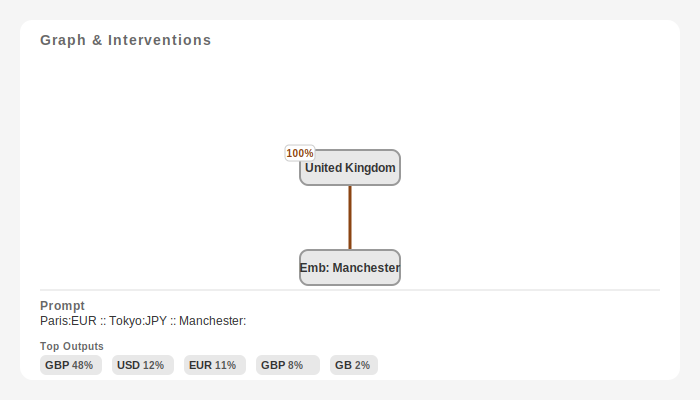

In [28]:
# Swap graph with Manchester

prompt = "Paris:EUR :: Tokyo:JPY :: Manchester:"
tokens = model.tokenizer.encode(prompt)
last_pos = len(tokens) - 1

# Source activations from Mumbai
source_prompt = "Paris:EUR :: Tokyo:JPY :: Mumbai:"
source_tokens = model.tokenizer.encode(source_prompt)
source_last_pos = len(source_tokens) - 1
_, source_activations = model.get_activations(source_prompt)

# Embedding node
city_emb_node = Supernode(name="Emb: Manchester", features=None, children=[])

# UK node
uk_node = Supernode(
    name="United Kingdom",
    features=[Feature(layer=f.layer, pos=last_pos, feature_idx=f.feature_idx) for f in uk_features],
)

city_emb_node.children = [uk_node]

ordered_nodes = [
    [city_emb_node],
    [uk_node],
]

graph = InterventionGraph(ordered_nodes=ordered_nodes, prompt=prompt)

logits, activations = model.get_activations(prompt)
graph.initialize_node(uk_node, activations)

# Initialize India from Mumbai
india_node = Supernode(
    name="India",
    features=[Feature(layer=f.layer, pos=last_pos, feature_idx=f.feature_idx) for f in india_features],
)
india_source = Supernode(
    name="India_source",
    features=[Feature(layer=f.layer, pos=source_last_pos, feature_idx=f.feature_idx) for f in india_features],
)
source_graph = InterventionGraph(ordered_nodes=[[india_source]], prompt=source_prompt)
source_graph.initialize_node(india_source, source_activations)
india_node.default_activations = india_source.default_activations
graph.nodes["India"] = india_node

graph.set_node_activation_fractions(activations)

# Baseline
top_outputs = get_top_outputs(logits)
print("Baseline:")
create_graph_visualization(graph, top_outputs)

Then, we graph the result of negatively steering the UK node and amplifying the India node.

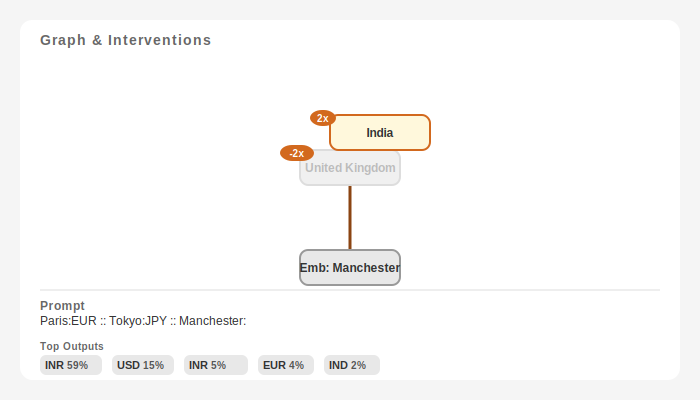

In [29]:
def supernode_intervention(intervention_graph, interventions, replacements=None):
    intervention_values = [
        (*feature, scaling_factor * default_act)
        for intervened_supernode, scaling_factor in interventions
        for feature, default_act in zip(
            intervened_supernode.features, intervened_supernode.default_activations
        )
    ]
    new_logits, new_activations = model.feature_intervention(
        intervention_graph.prompt, intervention_values
    )
    intervention_graph.set_node_activation_fractions(new_activations)
    top_outputs = get_top_outputs(new_logits)

    for intervened_supernode, scaling_factor in interventions:
        intervened_supernode.activation = None
        intervened_supernode.intervention = f"{scaling_factor}x"

    if replacements is not None:
        for target, replacement in replacements.items():
            intervention_graph.nodes[target].replacement_node = replacement

    return create_graph_visualization(intervention_graph, top_outputs)

# Swap: -2x UK, 2x India
supernode_intervention(
    graph,
    [Intervention(uk_node, -2), Intervention(india_node, 2)],
    {uk_node.name: india_node},
)